In [9]:
import numpy as np
import matplotlib.pyplot as plt

train_images = np.load('../data/processed/train_images.npy')  # (60000, 28, 28)
train_labels = np.load('../data/processed/train_labels.npy')  # (60000,)
test_images = np.load('../data/processed/test_images.npy')
test_labels = np.load('../data/processed/test_labels.npy')

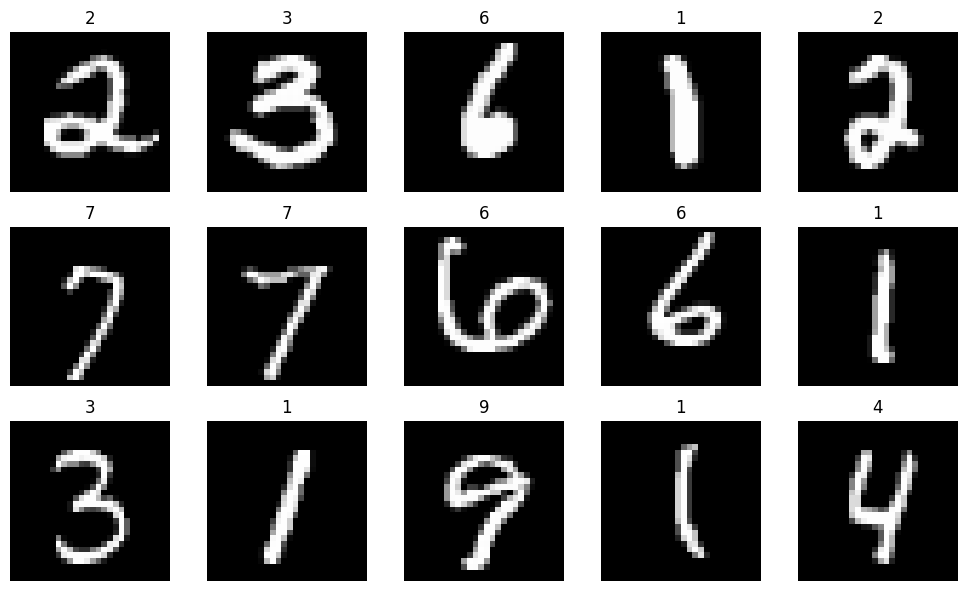

In [10]:
n = 15
total = len(train_images)
random_indices = np.random.choice(total, n, replace=False)
fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for i, ax in enumerate(axes.flat):
    idx = random_indices[i]
    ax.imshow(train_images[idx], cmap='gray')
    ax.set_title(train_labels[idx])
    ax.axis('off')

plt.tight_layout()
plt.show()

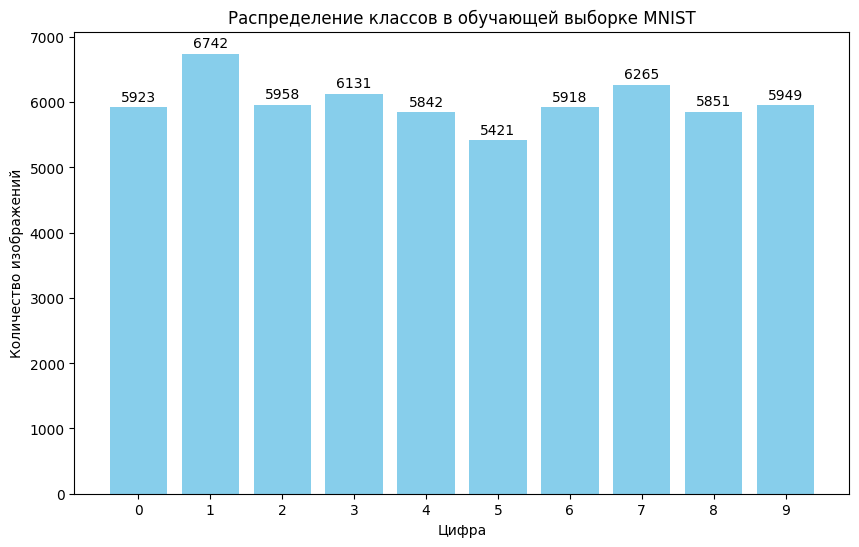

In [11]:
unique, counts = np.unique(train_labels, return_counts=True)

plt.figure(figsize=(10, 6))
bars = plt.bar(unique, counts, color='skyblue')
plt.xticks(unique)
plt.xlabel('Цифра')
plt.ylabel('Количество изображений')
plt.title('Распределение классов в обучающей выборке MNIST')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50, f'{int(height)}', ha='center', va='bottom')

plt.show()

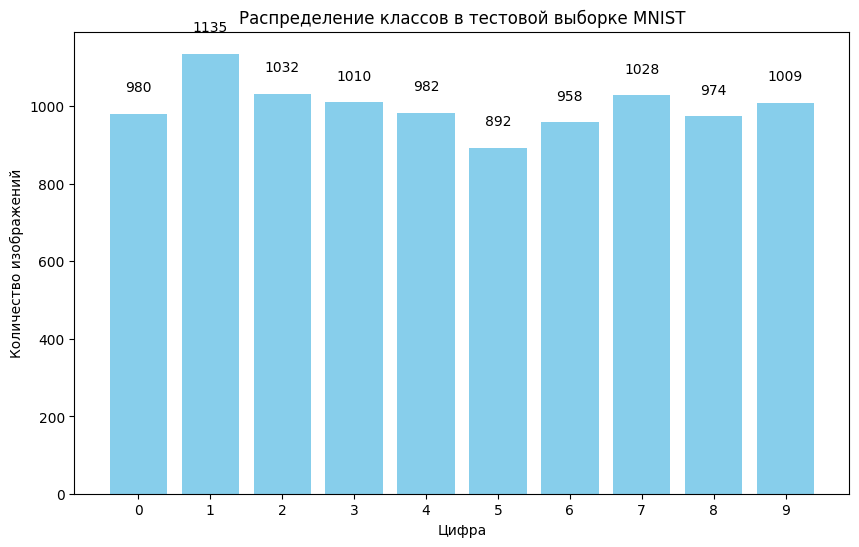

In [13]:
unique, counts = np.unique(test_labels, return_counts=True)

plt.figure(figsize=(10, 6))
bars = plt.bar(unique, counts, color='skyblue')
plt.xticks(unique)
plt.xlabel('Цифра')
plt.ylabel('Количество изображений')
plt.title('Распределение классов в тестовой выборке MNIST')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50, f'{int(height)}', ha='center', va='bottom')

plt.show()

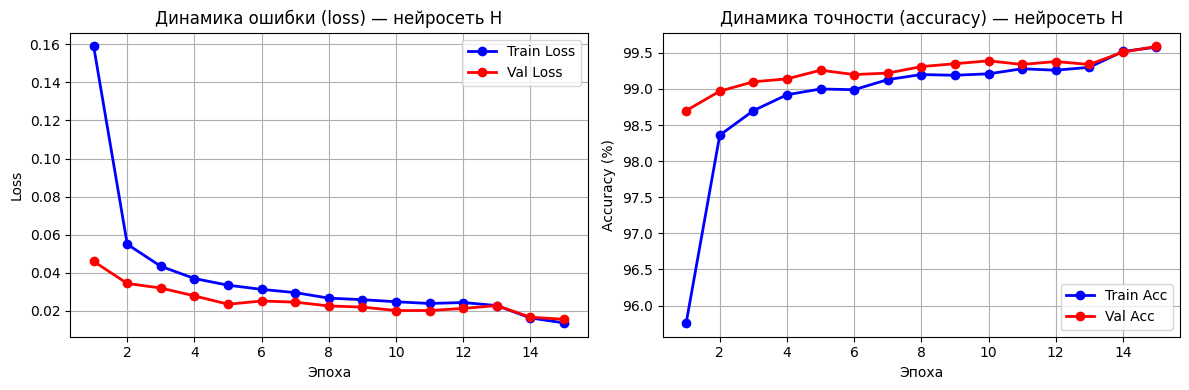

Лучшая точность на валидации: 99.59% (эпоха 15)
Финальная точность на тесте: 99.54% (по отчёту Н)


In [3]:
import matplotlib.pyplot as plt
epochs = list(range(1, 16))

train_loss = [0.1589, 0.0550, 0.0434, 0.0370, 0.0335, 0.0313, 0.0296, 0.0267, 
              0.0259, 0.0248, 0.0239, 0.0244, 0.0228, 0.0163, 0.0137]

val_loss = [0.0460, 0.0344, 0.0320, 0.0279, 0.0235, 0.0252, 0.0246, 0.0226, 
            0.0220, 0.0202, 0.0202, 0.0213, 0.0228, 0.0167, 0.0156]

train_acc = [95.76, 98.36, 98.70, 98.92, 99.00, 98.99, 99.13, 99.20, 
             99.19, 99.21, 99.28, 99.26, 99.30, 99.52, 99.58]

val_acc = [98.70, 98.97, 99.10, 99.14, 99.26, 99.20, 99.22, 99.31, 
           99.35, 99.39, 99.34, 99.38, 99.34, 99.51, 99.59]

# Рисуем loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-o', label='Train Loss', linewidth=2)
plt.plot(epochs, val_loss, 'r-o', label='Val Loss', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Динамика ошибки (loss) — нейросеть Н')
plt.legend()
plt.grid(True)

# Рисуем accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'b-o', label='Train Acc', linewidth=2)
plt.plot(epochs, val_acc, 'r-o', label='Val Acc', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Accuracy (%)')
plt.title('Динамика точности (accuracy) — нейросеть Н')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

# Дополнительно: вывести лучшие результаты
print(f"Лучшая точность на валидации: {max(val_acc):.2f}% (эпоха {val_acc.index(max(val_acc))+1})")
print(f"Финальная точность на тесте: 99.54% (по отчёту Н)")